# Mount Drive and Unzip

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Confirm the zip is actually visible at that path:

In [ ]:
!ls "/content/drive/MyDrive/" | grep animal

animal_datsets.zip


##Unzip into your cloned repo folder:

In [ ]:
!unzip -q "/content/drive/MyDrive/animal_datsets.zip" -d "/content/diffusion-animal-generation/Saad_MSDS25066_05/"

##Verify it landed correctly:

In [ ]:
!ls "/content/diffusion-animal-generation/Saad_MSDS25066_05/"

animal_data


##Confirm Colab gave GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
Device name: Tesla T4


In [ ]:
%cd /content/diffusion-animal-generation
!git pull
%cd Saad_MSDS25066_05

/content/diffusion-animal-generation
Already up to date.
/content/diffusion-animal-generation/Saad_MSDS25066_05


# Real training on the GPU

In [ ]:
!ls /content/diffusion-animal-generation/Saad_MSDS25066_05/

animal_data


In [ ]:
!find /content -name "MSDS25066_05_train.py"

/content/diffusion-animal-generation/MSDS25066_05_train.py


##Fix: use the correct path directly

In [ ]:
!find /content/diffusion-animal-generation -maxdepth 2

/content/diffusion-animal-generation
/content/diffusion-animal-generation/animal_data
/content/diffusion-animal-generation/animal_data/Cat
/content/diffusion-animal-generation/animal_data/Giraffe
/content/diffusion-animal-generation/animal_data/Zebra
/content/diffusion-animal-generation/animal_data/Kangaroo
/content/diffusion-animal-generation/animal_data/Tiger
/content/diffusion-animal-generation/animal_data/Bear
/content/diffusion-animal-generation/animal_data/Lion
/content/diffusion-animal-generation/animal_data/Dolphin
/content/diffusion-animal-generation/animal_data/Deer
/content/diffusion-animal-generation/animal_data/Bird
/content/diffusion-animal-generation/animal_data/Dog
/content/diffusion-animal-generation/animal_data/Horse
/content/diffusion-animal-generation/animal_data/Cow
/content/diffusion-animal-generation/animal_data/Panda
/content/diffusion-animal-generation/animal_data/Elephant
/content/diffusion-animal-generation/.git
/content/diffusion-animal-generation/.git/descr

##The simple fix: just use the correct path in Colab

In [ ]:
import sys
sys.path.insert(0, '/content/diffusion-animal-generation')

from MSDS25066_05_train import *

In [ ]:
%cd /content/diffusion-animal-generation
!mv Saad_MSDS25066_05/animal_data .
!ls

/content/diffusion-animal-generation
mv: cannot move 'Saad_MSDS25066_05/animal_data' to './animal_data': Directory not empty
animal_data		    MSDS25066_05_train.py  Saad_MSDS25066_05
forward_diffusion_test.png  __pycache__		   saved_models
MSDS25066_05_test.py	    Readme.txt		   test_single_sample.ipynb


In [ ]:
import sys
sys.path.insert(0, '/content/diffusion-animal-generation')

from MSDS25066_05_train import *

In [ ]:
%cd /content/diffusion-animal-generation
!git pull

/content/diffusion-animal-generation
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 10 (delta 4), reused 9 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 6.68 MiB | 31.80 MiB/s, done.
From https://github.com/Hashimi321/diffusion-animal-generation
   14b765f..4d92c8b  main       -> origin/main
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configure

In [ ]:
import importlib
import sys
if 'MSDS25066_05_train' in sys.modules:
    del sys.modules['MSDS25066_05_train']

sys.path.insert(0, '/content/diffusion-animal-generation')
from MSDS25066_05_train import *

# Training  

In [ ]:
classes = ["Bear", "Cat", "Dog", "Lion", "Tiger"]
dataset = AnimalDiffusionDataset(root_dir="animal_data", classes=classes, transform=image_transform)
print("Total images:", len(dataset))

model = UNet()
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", device)

train_model(model, dataset, epochs=50, batch_size=8, learning_rate=1e-4, device=device)

Total images: 100
Training on: cuda
Epoch 1/50 — Loss: 0.9311
Epoch 2/50 — Loss: 0.5492
Epoch 3/50 — Loss: 0.3351
Epoch 4/50 — Loss: 0.2067
Epoch 5/50 — Loss: 0.1590
Epoch 6/50 — Loss: 0.1661
Epoch 7/50 — Loss: 0.1278
Epoch 8/50 — Loss: 0.1359
Epoch 9/50 — Loss: 0.1199
Epoch 10/50 — Loss: 0.1214
Epoch 11/50 — Loss: 0.1143
Epoch 12/50 — Loss: 0.1350
Epoch 13/50 — Loss: 0.1272
Epoch 14/50 — Loss: 0.0929
Epoch 15/50 — Loss: 0.1085
Epoch 16/50 — Loss: 0.0920
Epoch 17/50 — Loss: 0.0862
Epoch 18/50 — Loss: 0.0673
Epoch 19/50 — Loss: 0.1038
Epoch 20/50 — Loss: 0.0782
Epoch 21/50 — Loss: 0.0774
Epoch 22/50 — Loss: 0.0688
Epoch 23/50 — Loss: 0.0739
Epoch 24/50 — Loss: 0.0645
Epoch 25/50 — Loss: 0.0687
Epoch 26/50 — Loss: 0.0679
Epoch 27/50 — Loss: 0.0545
Epoch 28/50 — Loss: 0.0669
Epoch 29/50 — Loss: 0.0878
Epoch 30/50 — Loss: 0.0638
Epoch 31/50 — Loss: 0.0548
Epoch 32/50 — Loss: 0.0540
Epoch 33/50 — Loss: 0.0702
Epoch 34/50 — Loss: 0.0503
Epoch 35/50 — Loss: 0.0739
Epoch 36/50 — Loss: 0.0556
E

##Download the trained model from Colab

In [ ]:
from google.colab import files
files.download('/content/diffusion-animal-generation/saved_models/diffusion_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Again Training With Visualization

In [ ]:
!git fetch origin
!git reset --hard origin/main

HEAD is now at 4d92c8b feat: add generate_image function implementing reverse diffusion sampling loop


In [ ]:
import sys
if 'MSDS25066_05_train' in sys.modules:
    del sys.modules['MSDS25066_05_train']
sys.path.insert(0, '/content/diffusion-animal-generation')
from MSDS25066_05_train import *

Epoch 1/50 — Loss: 0.8395
Epoch 2/50 — Loss: 0.4667
Epoch 3/50 — Loss: 0.2738
Epoch 4/50 — Loss: 0.1691
Epoch 5/50 — Loss: 0.1682
Epoch 6/50 — Loss: 0.1524
Epoch 7/50 — Loss: 0.1272
Epoch 8/50 — Loss: 0.1152
Epoch 9/50 — Loss: 0.1122
Epoch 10/50 — Loss: 0.1070
Epoch 11/50 — Loss: 0.0881
Epoch 12/50 — Loss: 0.0850
Epoch 13/50 — Loss: 0.0872
Epoch 14/50 — Loss: 0.0721
Epoch 15/50 — Loss: 0.0860
Epoch 16/50 — Loss: 0.0827
Epoch 17/50 — Loss: 0.0842
Epoch 18/50 — Loss: 0.0777
Epoch 19/50 — Loss: 0.0801
Epoch 20/50 — Loss: 0.0717
Epoch 21/50 — Loss: 0.0964
Epoch 22/50 — Loss: 0.0804
Epoch 23/50 — Loss: 0.0742
Epoch 24/50 — Loss: 0.0653
Epoch 25/50 — Loss: 0.0542
Epoch 26/50 — Loss: 0.0723
Epoch 27/50 — Loss: 0.0756
Epoch 28/50 — Loss: 0.0683
Epoch 29/50 — Loss: 0.0540
Epoch 30/50 — Loss: 0.0691
Epoch 31/50 — Loss: 0.0525
Epoch 32/50 — Loss: 0.0574
Epoch 33/50 — Loss: 0.0578
Epoch 34/50 — Loss: 0.0581
Epoch 35/50 — Loss: 0.0544
Epoch 36/50 — Loss: 0.0463
Epoch 37/50 — Loss: 0.0432
Epoch 38/5

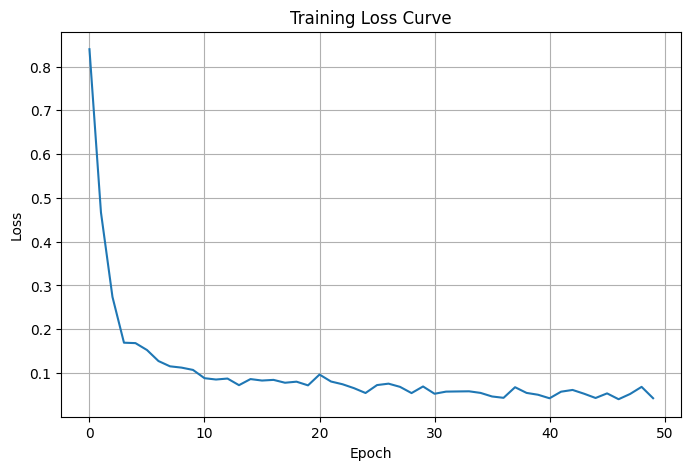

Loss curve saved.


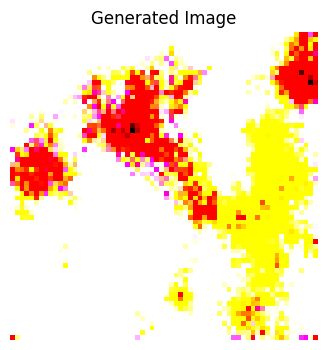

Generated sample saved.


In [ ]:
classes = ["Bear", "Cat", "Dog", "Lion", "Tiger"]
dataset = AnimalDiffusionDataset(root_dir="animal_data", classes=classes, transform=image_transform)
model = UNet()
device = "cuda" if torch.cuda.is_available() else "cpu"

loss_history = train_model(model, dataset, epochs=50, batch_size=8, learning_rate=1e-4, device=device)

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.savefig("/content/diffusion-animal-generation/loss_curve.png")
plt.show()
print("Loss curve saved.")

# Generate a sample image from pure noise
generated = generate_image(model, alpha_bars, betas, alphas, T, device=device)
img_to_show = (generated.clamp(-1, 1) + 1) / 2
img_to_show = img_to_show.squeeze(0).permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_to_show)
plt.axis("off")
plt.title("Generated Image")
plt.savefig("/content/diffusion-animal-generation/generated_sample.png")
plt.show()
print("Generated sample saved.")

##Download all three files

In [ ]:
from google.colab import files
files.download('/content/diffusion-animal-generation/saved_models/diffusion_model.pth')
files.download('/content/diffusion-animal-generation/loss_curve.png')
files.download('/content/diffusion-animal-generation/generated_sample.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# New Training With 200 Epoch

In [ ]:
%cd /content/diffusion-animal-generation
!git fetch origin
!git reset --hard origin/main

/content/diffusion-animal-generation
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 486 bytes | 486.00 KiB/s, done.
From https://github.com/Hashimi321/diffusion-animal-generation
   4d92c8b..13472a5  main       -> origin/main
HEAD is now at 13472a5 feat: properly inject time embedding into ConvBlocks via projection and broadcast-add


In [ ]:
import sys
if 'MSDS25066_05_train' in sys.modules:
    del sys.modules['MSDS25066_05_train']
sys.path.insert(0, '/content/diffusion-animal-generation')
from MSDS25066_05_train import *

Epoch 1/200 — Loss: 0.8627
Epoch 2/200 — Loss: 0.5206
Epoch 3/200 — Loss: 0.3583
Epoch 4/200 — Loss: 0.2261
Epoch 5/200 — Loss: 0.1779
Epoch 6/200 — Loss: 0.1504
Epoch 7/200 — Loss: 0.1406
Epoch 8/200 — Loss: 0.1160
Epoch 9/200 — Loss: 0.1185
Epoch 10/200 — Loss: 0.1035
Epoch 11/200 — Loss: 0.1251
Epoch 12/200 — Loss: 0.0952
Epoch 13/200 — Loss: 0.0902
Epoch 14/200 — Loss: 0.1065
Epoch 15/200 — Loss: 0.1117
Epoch 16/200 — Loss: 0.1060
Epoch 17/200 — Loss: 0.0749
Epoch 18/200 — Loss: 0.0807
Epoch 19/200 — Loss: 0.0739
Epoch 20/200 — Loss: 0.0915
Epoch 21/200 — Loss: 0.0673
Epoch 22/200 — Loss: 0.0745
Epoch 23/200 — Loss: 0.0783
Epoch 24/200 — Loss: 0.0600
Epoch 25/200 — Loss: 0.0631
Epoch 26/200 — Loss: 0.0684
Epoch 27/200 — Loss: 0.0528
Epoch 28/200 — Loss: 0.0562
Epoch 29/200 — Loss: 0.0642
Epoch 30/200 — Loss: 0.0466
Epoch 31/200 — Loss: 0.0491
Epoch 32/200 — Loss: 0.0643
Epoch 33/200 — Loss: 0.0515
Epoch 34/200 — Loss: 0.0603
Epoch 35/200 — Loss: 0.0668
Epoch 36/200 — Loss: 0.0760
E

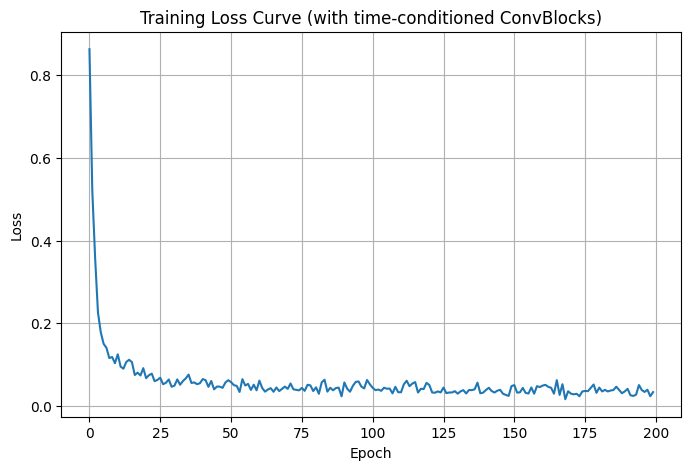

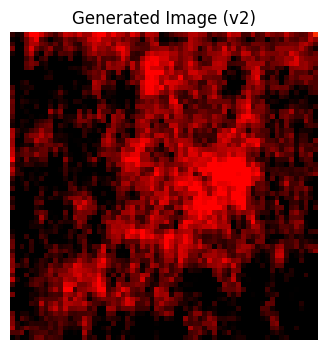

In [ ]:
classes = ["Bear", "Cat", "Dog", "Lion", "Tiger"]
dataset = AnimalDiffusionDataset(root_dir="animal_data", classes=classes, transform=image_transform)
model = UNet()
device = "cuda" if torch.cuda.is_available() else "cpu"

loss_history = train_model(model, dataset, epochs=200, batch_size=8, learning_rate=1e-4, device=device)

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (with time-conditioned ConvBlocks)")
plt.grid(True)
plt.savefig("/content/diffusion-animal-generation/loss_curve_v2.png")
plt.show()

generated = generate_image(model, alpha_bars, betas, alphas, T, device=device)
img_to_show = (generated.clamp(-1, 1) + 1) / 2
img_to_show = img_to_show.squeeze(0).permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_to_show)
plt.axis("off")
plt.title("Generated Image (v2)")
plt.savefig("/content/diffusion-animal-generation/generated_sample_v2.png")
plt.show()

In [ ]:
from google.colab import files
files.download('/content/diffusion-animal-generation/saved_models/diffusion_model.pth')
files.download('/content/diffusion-animal-generation/loss_curve_v2.png')
files.download('/content/diffusion-animal-generation/generated_sample_v2.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>